In [132]:
%load_ext autoreload
%autoreload 2

import gurobipy as gp
from gurobipy import GRB

from matplotlib import pyplot as plt

from first_model import Instance, Solution, Model
from utils import *

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# I. Test de plusieurs scénarios pour le modèle, avec et sans worker compétent pour les tâches

## I.1 Au moins un worker compétent pour chaque métier

In [71]:
instance_generated = Instance()
instance_generated.from_random(at_least_a_worker_have_competence_for_each_profession=True, seed=42)
print(instance_generated)


 ===== Start of Instance: =====
Number of jobs: 2
Number of professions: 4
Number of tasks per profession: [2 2 2 3]
Max number of operations per Jobs: 4
Total number of tasks: 9
Total number of workers: 3
Task to profession mapping:
{0: 0, 1: 0, 2: 1, 3: 1, 4: 2, 5: 2, 6: 3, 7: 3, 8: 3}
Worker levels: shape=(3, 4)
 [[2 2 4 2]
 [4 4 3 4]
 [2 3 4 1]]
Job difficulties: shape= (2,)
[4 4]
Task difficulties: shape= (9,)
[4 3 4 1 4 3 3 2 1]
Task processing times: shape= (9, 3)
[[ 7.         10.37096069  3.66332982]
 [19.         22.80443897 18.75067743]
 [11.         16.47429815 -1.        ]
 [11.         15.23768898  5.99833539]
 [ 4.          5.53398379  3.23677202]
 [ 8.          9.61695913  5.52984797]
 [ 3.          3.62075618 -1.        ]
 [ 2.          2.7148648   1.46676289]
 [12.         15.8394995  11.15964244]]
Jobs structure: len= 2
Job 0 : 	O_(0,0) = 7 	O_(0,1) = 4 	O_(0,2) = 1 
Job 1 : 	O_(1,0) = 4 	O_(1,1) = 7 	O_(1,2) = 8 

Precedence constraints: shape= (2, 4, 4)
[[[0. 1. 0

In [72]:
model = Model(instance_generated)
s = model.solve(objective="makespan", weight=[0, 0, 0], priority=[2, 1, 0], verbose=False)

Set parameter SolFiles to value "../results/intermediate_solutions.sol"
penalty deadline obj: 0
Optimal solution found with objective value: 23.703534911914176
ici ->  1
nObjectives 1
nSolutions 6


In [73]:
gantt_chart(s, instance_generated, color=3, render= "notebook", verbose=False)

,Task,Start,Finish,Finish (var. f),Processing time,Operation,Job,mode,Level_w,Difficulty_task,Elementary task,Metier
0,w1,0.000000,1.466763,1.466763,1.466763,"(1,1)",J1,collaboratively,2,2,7.0,3.0
1,w1,1.466763,4.703535,4.703535,3.236772,"(1,2)",J1,collaboratively,4,4,4.0,2.0
2,w1,8.703535,11.418400,11.418400,2.714865,"(2,2)",J2,learning (tutor),2,2,7.0,3.0
3,w2,0.000000,1.466763,1.466763,1.466763,"(1,1)",J1,collaboratively,4,2,7.0,3.0
4,w2,4.703535,23.703535,23.703535,19.000000,"(1,3)",J1,alone,4,3,1.0,0.0
5,w3,1.466763,4.703535,4.703535,3.236772,"(1,2)",J1,collaboratively,4,4,4.0,2.0
6,w3,4.703535,8.703535,8.703535,4.000000,"(2,1)",J2,alone,4,4,4.0,2.0
7,w3,8.703535,11.418400,11.418400,2.714865,"(2,2)",J2,learning (apprentice),1,2,7.0,3.0
8,w3,11.418400,23.418400,23.418400,12.000000,"(2,3)",J2,alone,1,1,8.0,3.0


In [74]:
x, y, z = [], [], []

for i in range(len(s.penalty_levels)):
    for j in range(len(s.penalty_levels[i])):
        if s.penalty_levels[i, j] > 0: #si il y a une pénalité on la stocke pour l'afficher ensuite
            print(f"Opération {j} du job {i} a une pénalité de {s.penalty_levels[i, j]}")
            x.append(i)
            y.append(j)
            z.append(s.penalty_levels[i, j])

if len(x) > 0:
    z = np.array(z)
    plt.scatter(x, y, s=z*500)
    plt.xticks(range(instance_generated.nb_jobs))
    plt.yticks(range(instance_generated.max_nb_operations))
    plt.xlabel("Job")
    plt.ylabel("Opération")
    plt.title("Pénalités pour les opérations faites en solo par un worker qui n'a pas le niveau requis")
    plt.grid()
    plt.show()
else :
    print("Aucune opération n'a été faite en solo par un worker qui n'a pas le niveau requis, il n'y a donc aucune pénalité à afficher.")

Aucune opération n'a été faite en solo par un worker qui n'a pas le niveau requis, il n'y a donc aucune pénalité à afficher.


- **Aucune opération fait par un worker solo non compétent (pas de pénalité)**
- **On peut voir que une opération à été fait en apprentissage (teaching task)**

## I.1a Avec la même instance mais en refusant les taches d'enseignement (teaching tasks) :

In [75]:
s = model.solve(objective="makespan", weight=[0, 0, 0], priority=[2, 1, 0], constraints_config={"no_teaching_tasks": True}, verbose=False)

Set parameter SolFiles to value "../results/intermediate_solutions.sol"
penalty deadline obj: 0
Optimal solution found with objective value: 23.70353491191416
ici ->  1
nObjectives 1
nSolutions 5


In [76]:
gantt_chart(s, instance_generated, color=3, render= "notebook", verbose=False)

,Task,Start,Finish,Finish (var. f),Processing time,Operation,Job,mode,Level_w,Difficulty_task,Elementary task,Metier
0,w1,0.000000,1.466763,1.466763,1.466763,"(1,1)",J1,collaboratively,2,2,7.0,3.0
1,w1,1.466763,4.703535,4.703535,3.236772,"(1,2)",J1,collaboratively,4,4,4.0,2.0
2,w1,4.703535,8.703535,8.703535,4.000000,"(2,1)",J2,alone,4,4,4.0,2.0
3,w1,8.703535,10.703535,10.703535,2.000000,"(2,2)",J2,alone,2,2,7.0,3.0
4,w2,0.000000,1.466763,1.466763,1.466763,"(1,1)",J1,collaboratively,4,2,7.0,3.0
5,w2,4.703535,23.703535,23.703535,19.000000,"(1,3)",J1,alone,4,3,1.0,0.0
6,w3,1.466763,4.703535,4.703535,3.236772,"(1,2)",J1,collaboratively,4,4,4.0,2.0
7,w3,10.703535,22.703535,22.703535,12.000000,"(2,3)",J2,alone,1,1,8.0,3.0


- **On peut voir à présent qu'aucune tache d'enseignement n'est faite, et que une opération est faite par un worker solo non compétent, ce qui engendre une pénalité**
- **La valeur du makespan est inchangée**

## I.2 Sans forcer le fait qu'il doit y avoir au moins un worker compétent pour chaque métier

In [77]:
instance_generated = Instance()
instance_generated.from_random(at_least_a_worker_have_competence_for_each_profession=False, seed=42)
print(instance_generated)


 ===== Start of Instance: =====
Number of jobs: 2
Number of professions: 4
Number of tasks per profession: [2 2 2 3]
Max number of operations per Jobs: 4
Total number of tasks: 9
Total number of workers: 3
Task to profession mapping:
{0: 0, 1: 0, 2: 1, 3: 1, 4: 2, 5: 2, 6: 3, 7: 3, 8: 3}
Worker levels: shape=(3, 4)
 [[2 2 2 2]
 [2 2 2 1]
 [3 2 2 2]]
Job difficulties: shape= (2,)
[3 4]
Task difficulties: shape= (9,)
[4 3 4 1 4 3 3 2 1]
Task processing times: shape= (9, 3)
[[ 7.         10.37096069  3.66332982]
 [19.         22.80443897 18.75067743]
 [11.         16.47429815 -1.        ]
 [11.         15.23768898  5.99833539]
 [ 4.          5.53398379  3.23677202]
 [ 8.          9.61695913  5.52984797]
 [ 3.          3.62075618 -1.        ]
 [ 2.          2.7148648   1.46676289]
 [12.         15.8394995  11.15964244]]
Jobs structure: len= 2
Job 0 : 	O_(0,0) = 3 	O_(0,1) = 7 	O_(0,2) = 6 
Job 1 : 	O_(1,0) = 8 	O_(1,1) = 7 	O_(1,2) = 4 

Precedence constraints: shape= (2, 4, 4)
[[[0. 1. 0

In [78]:
model = Model(instance_generated)
s = model.solve(objective="makespan", weight=[0, 0, 0], priority=[2, 1, 0], verbose=False)

Set parameter SolFiles to value "../results/intermediate_solutions.sol"
penalty deadline obj: 0
Optimal solution found with objective value: 318.6264053336658
ici ->  1
nObjectives 1
nSolutions 8


In [79]:
gantt_chart(s, instance_generated, color=3, render= "notebook", verbose=False)

,Task,Start,Finish,Finish (var. f),Processing time,Operation,Job,mode,Level_w,Difficulty_task,Elementary task,Metier
0,w1,0.000000,11.159642,11.159642,11.159642,"(2,1)",J2,collaboratively,2,1,8.0,3.0
1,w1,11.159642,12.626405,12.626405,1.466763,"(2,2)",J2,collaboratively,2,2,7.0,3.0
2,w1,12.626405,14.093168,14.093168,1.466763,"(1,2)",J1,collaboratively,2,2,7.0,3.0
3,w1,14.093168,18.593168,18.593168,4.500000,"(1,3)",J1,alone without levels,2,3,6.0,3.0
4,w2,0.000000,11.159642,11.159642,11.159642,"(2,1)",J2,collaboratively,1,1,8.0,3.0
5,w2,12.626405,18.626405,18.626405,6.000000,"(2,3)",J2,alone without levels,2,4,4.0,2.0
6,w3,0.000000,11.000000,11.000000,11.000000,"(1,1)",J1,alone,2,1,3.0,1.0
7,w3,11.159642,12.626405,12.626405,1.466763,"(2,2)",J2,collaboratively,2,2,7.0,3.0
8,w3,12.626405,14.093168,14.093168,1.466763,"(1,2)",J1,collaboratively,2,2,7.0,3.0


Opération 2 du job 0 a une pénalité de 1.0
Opération 2 du job 1 a une pénalité de 2.0


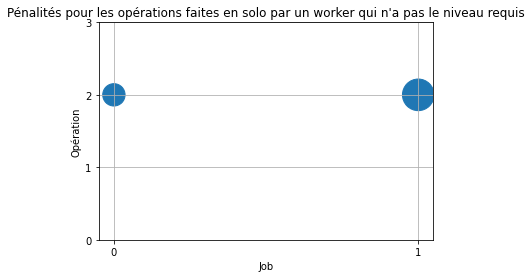

In [80]:
x, y, z = [], [], []

for i in range(len(s.penalty_levels)):
    for j in range(len(s.penalty_levels[i])):
        if s.penalty_levels[i, j] > 0: #si il y a une pénalité on la stocke pour l'afficher ensuite
            print(f"Opération {j} du job {i} a une pénalité de {s.penalty_levels[i, j]}")
            x.append(i)
            y.append(j)
            z.append(s.penalty_levels[i, j])

if len(x) > 0:
    z = np.array(z)
    plt.scatter(x, y, s=z*500)
    plt.xticks(range(instance_generated.nb_jobs))
    plt.yticks(range(instance_generated.max_nb_operations))
    plt.xlabel("Job")
    plt.ylabel("Opération")
    plt.title("Pénalités pour les opérations faites en solo par un worker qui n'a pas le niveau requis")
    plt.grid()
    plt.show()
else :
    print("Aucune opération n'a été faite en solo par un worker qui n'a pas le niveau requis, il n'y a donc aucune pénalité à afficher.")

## I.2a On va forcer encore plus en diminuant de 1 le levels de chaque worker

In [81]:
print("Avant de diminuer les niveaux des workers :")
print(instance_generated.levels_workers)

for i in range(len(instance_generated.levels_workers)):
    for j in range(len(instance_generated.levels_workers[i])):
        instance_generated.levels_workers[i][j] = max(1, instance_generated.levels_workers[i][j] - 1)

print("Après avoir diminué les niveaux des workers de 1 :")
print(instance_generated.levels_workers)

Avant de diminuer les niveaux des workers :
[[2 2 2 2]
 [2 2 2 1]
 [3 2 2 2]]
Après avoir diminué les niveaux des workers de 1 :
[[1 1 1 1]
 [1 1 1 1]
 [2 1 1 1]]


In [82]:
model = Model(instance_generated)
s = model.solve(objective="makespan", weight=[0, 0, 0], priority=[2, 1, 0], verbose=False)

Set parameter SolFiles to value "../results/intermediate_solutions.sol"
penalty deadline obj: 0
Optimal solution found with objective value: 720.1596424404129
ici ->  1
nObjectives 1
nSolutions 6


In [83]:
gantt_chart(s, instance_generated, color=3, render= "notebook", verbose=False)

,Task,Start,Finish,Finish (var. f),Processing time,Operation,Job,mode,Level_w,Difficulty_task,Elementary task,Metier
0,w1,0.000000,11.000000,11.000000,11.000000,"(1,1)",J1,alone,1,1,3.0,1.0
1,w1,15.659642,20.159642,20.159642,4.500000,"(1,3)",J1,alone without levels,1,3,6.0,3.0
2,w2,-0.000000,11.159642,11.159642,11.159642,"(2,1)",J2,collaboratively,1,1,8.0,3.0
3,w2,11.159642,14.159642,14.159642,3.000000,"(2,2)",J2,alone without levels,1,2,7.0,3.0
4,w2,14.159642,20.159642,20.159642,6.000000,"(2,3)",J2,alone without levels,1,4,4.0,2.0
5,w3,0.000000,11.159642,11.159642,11.159642,"(2,1)",J2,collaboratively,1,1,8.0,3.0
6,w3,11.159642,14.159642,14.159642,3.000000,"(1,2)",J1,alone without levels,1,2,7.0,3.0


Opération 1 du job 0 a une pénalité de 1.0
Opération 2 du job 0 a une pénalité de 2.0
Opération 1 du job 1 a une pénalité de 1.0
Opération 2 du job 1 a une pénalité de 3.0


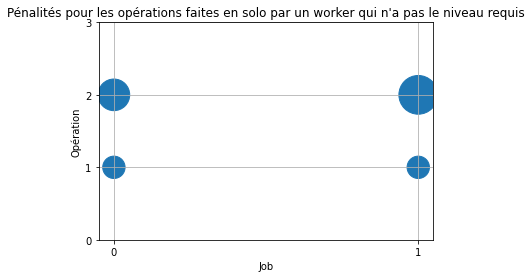

In [84]:
x, y, z = [], [], []

for i in range(len(s.penalty_levels)):
    for j in range(len(s.penalty_levels[i])):
        if s.penalty_levels[i, j] > 0: #si il y a une pénalité on la stocke pour l'afficher ensuite
            print(f"Opération {j} du job {i} a une pénalité de {s.penalty_levels[i, j]}")
            x.append(i)
            y.append(j)
            z.append(s.penalty_levels[i, j])

if len(x) > 0:
    z = np.array(z)
    plt.scatter(x, y, s=z*500)
    plt.xticks(range(instance_generated.nb_jobs))
    plt.yticks(range(instance_generated.max_nb_operations))
    plt.xlabel("Job")
    plt.ylabel("Opération")
    plt.title("Pénalités pour les opérations faites en solo par un worker qui n'a pas le niveau requis")
    plt.grid()
    plt.show()
else :
    print("Aucune opération n'a été faite en solo par un worker qui n'a pas le niveau requis, il n'y a donc aucune pénalité à afficher.")

## II. Résolution lexico-graphique

In [90]:
instance_generated = Instance()
instance_generated.from_random(at_least_a_worker_have_competence_for_each_profession=False, seed=2048)
# print(instance_generated)

### II.1 Makespan puis skills, puis cognitive load

In [91]:
model = Model(instance_generated)
s = model.solve(objective="lexicographic", weight=[0, 0, 0], priority=[2, 1, 0], verbose=False)

Set parameter SolFiles to value "../results/intermediate_solutions.sol"
penalty deadline obj: 0
Optimal solution found with objective value: 2.000201
ici ->  4
nObjectives 4
nSolutions 10


In [92]:
gantt_chart(s, instance_generated, color=3, render= "notebook", verbose=False)

,Task,Start,Finish,Finish (var. f),Processing time,Operation,Job,mode,Level_w,Difficulty_task,Elementary task,Metier
0,w1,0.000000,24.535181,24.535181,24.535181,"(3,1)",J3,learning (apprentice),1,2,2.0,0.0
1,w1,47.591246,51.150769,51.150769,3.559522,"(2,4)",J2,collaboratively,3,2,6.0,2.0
2,w2,0.000000,7.586131,7.586131,7.586131,"(2,1)",J2,collaboratively,2,2,9.0,3.0
3,w2,7.586131,26.586131,26.586131,19.000000,"(2,2)",J2,alone,3,3,4.0,1.0
4,w2,26.586131,35.586131,35.586131,9.000000,"(1,3)",J1,alone,3,3,3.0,1.0
5,w2,35.586131,47.586131,47.586131,12.000000,"(2,3)",J2,alone without levels,3,4,5.0,1.0
6,w2,47.591246,51.150769,51.150769,3.559522,"(2,4)",J2,collaboratively,2,2,6.0,2.0
7,w3,10.000000,24.919024,24.919024,14.919024,"(1,2)",J1,learning (apprentice),1,3,10.0,3.0
8,w3,27.895959,37.150769,37.150769,9.254810,"(3,3)",J3,learning (tutor),3,2,6.0,2.0
9,w3,38.047754,51.150769,51.150769,13.103015,"(3,4)",J3,collaboratively,3,2,8.0,2.0


O_(1,2) a une pénalité de 1.0
O_(2,0) a une pénalité de 0.00020100000000011775
O_(2,1) a une pénalité de 1.0


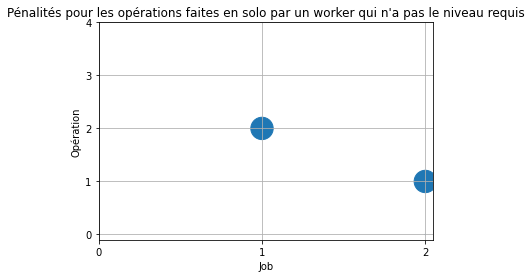

In [95]:
x, y, z = [], [], []

for i in range(len(s.penalty_levels)):
    for j in range(len(s.penalty_levels[i])):
        if s.penalty_levels[i, j] > 0: #si il y a une pénalité on la stocke pour l'afficher ensuite
            print(f"O_({i},{j}) a une pénalité de {s.penalty_levels[i, j]}")
            x.append(i)
            y.append(j)
            z.append(s.penalty_levels[i, j])

if len(x) > 0:
    z = np.array(z)
    plt.scatter(x, y, s=z*500)
    plt.xticks(range(instance_generated.nb_jobs))
    plt.yticks(range(instance_generated.max_nb_operations))
    plt.xlabel("Job")
    plt.ylabel("Opération")
    plt.title("Pénalités pour les opérations faites en solo par un worker qui n'a pas le niveau requis")
    plt.grid()
    plt.show()
else :
    print("Aucune opération n'a été faite en solo par un worker qui n'a pas le niveau requis, il n'y a donc aucune pénalité à afficher.")

#### **II.1a Affichage des charges cognitives totales par métier**

cognitive_load_total=
[[0.3 0.  0.5 0. ]
 [0.  0.  0.5 0.5]
 [0.  0.  1.2 0.3]
 [0.7 0.  0.  0. ]
 [0.  0.  0.3 0.5]
 [0.  0.  0.5 0.7]]


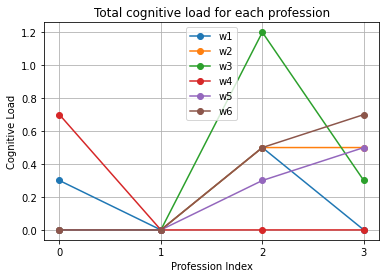

In [99]:
plot_cognitive_load_total(s, instance_generated, verbose=True)

- **le worker $w_3$ est celui qui à la charge cognitive la plus élevée pour le corps de métier 2**
- Après analyse on voit que le worker $w_3$ a fait des taches en tant que tuteur, apprenti et en collaboration, ce qui explique la charge cognitive élevée

#### **II.1b Affichage des skills totales par métier et par worker**

levels_workers=
[[[1.  1.  3.  1. ]
  [1.5 1.  3.  1. ]]

 [[1.  3.  2.  2. ]
  [1.  3.5 2.  2. ]]

 [[3.  2.  3.  1. ]
  [3.  2.  3.  1.5]]

 [[3.  2.  2.  1. ]
  [3.  2.  2.  1. ]]

 [[3.  2.  1.  2. ]
  [3.5 2.  1.5 2. ]]

 [[2.  2.  3.  3. ]
  [2.  2.  3.  3. ]]]


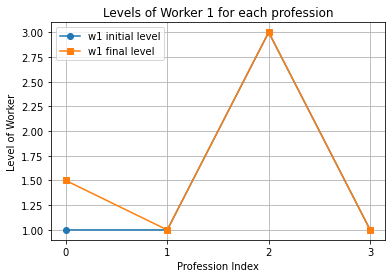

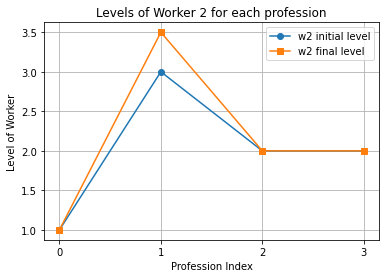

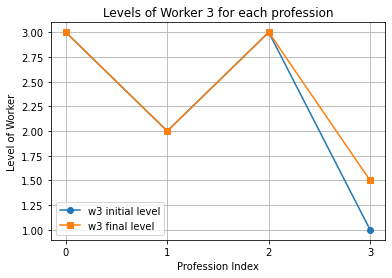

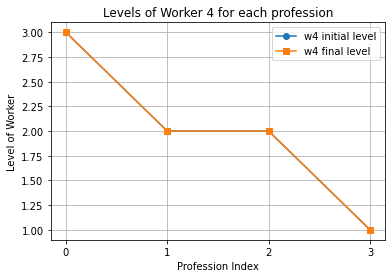

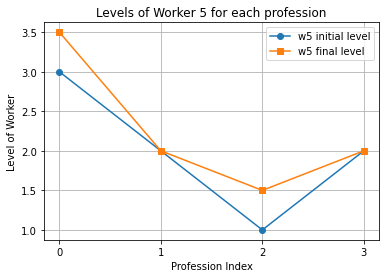

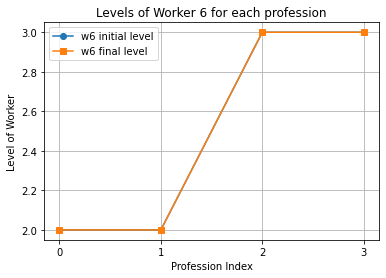

In [101]:
plot_levels_workers(s, instance_generated, verbose=True)

### III.A Lexicographic en priorisant les skills (à la toute fin on min forgetting)

In [142]:
instance_generated = Instance()
instance_generated.from_random(at_least_a_worker_have_competence_for_each_profession=False, seed=2048)
# print(instance_generated)
model = Model(instance_generated)
s = model.solve(objective="lexicographic", weight=[0, 0, 0], priority=[1, 2, 0], verbose=False)

Set parameter SolFiles to value "../results/intermediate_solutions.sol"
penalty deadline obj: 0
Optimal solution found with objective value: 2.000201
ici ->  5
nObjectives 5
nSolutions 10


In [143]:
gantt_chart(s, instance_generated, color=3, render= "notebook", verbose=False)

,Task,Start,Finish,Finish (var. f),Processing time,Operation,Job,mode,Level_w,Difficulty_task,Elementary task,Metier
0,w1,0.000000,24.535181,24.535181,24.535181,"(3,1)",J3,learning (apprentice),1,2,2.0,0.0
1,w1,37.976923,47.231733,47.231733,9.254810,"(3,3)",J3,learning (tutor),3,2,6.0,2.0
2,w1,55.356421,73.145007,73.145007,17.788586,"(1,4)",J1,learning (apprentice),1,2,9.0,3.0
3,w2,0.000000,14.919024,14.919024,14.919024,"(1,1)",J1,learning (apprentice),2,3,10.0,3.0
4,w2,17.788586,42.784070,42.784070,24.995483,"(2,2)",J2,learning (tutor),3,3,4.0,1.0
5,w2,42.784070,55.356421,55.356421,12.572351,"(1,3)",J1,learning (tutor),3,3,3.0,1.0
6,w2,57.592800,69.592800,69.592800,12.000000,"(2,3)",J2,alone without levels,3,4,5.0,1.0
7,w2,69.592800,73.152323,73.152323,3.559522,"(2,4)",J2,collaboratively,2,2,6.0,2.0
8,w3,0.000000,24.535181,24.535181,24.535181,"(3,1)",J3,learning (tutor),3,2,2.0,0.0
9,w3,24.535181,39.454205,39.454205,14.919024,"(1,2)",J1,learning (apprentice),1,3,10.0,3.0


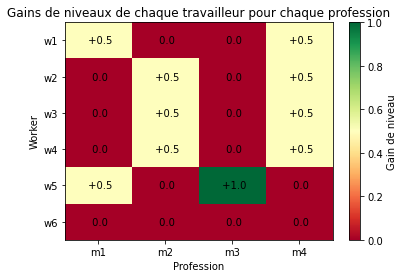

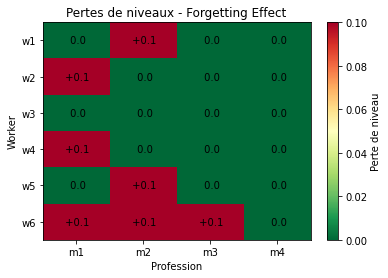

In [144]:
# plot_levels_workers(s, instance_generated, verbose=True)
resume_levels_workers(s, instance_generated, verbose=False)
resume_forgetting_effect_workers(s, instance_generated, verbose=False)

### III.B Lexicographic en priorisant les skills (on commence parmin forgetting)

# Test Forgetting effect